In [50]:
import pandas as pd
import numpy as np
import glob as glob
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import re
import duckdb
# from joblib import Parallel, delayed

# Loading in chunks

In [51]:
chunk_umi_count_paths = glob.glob("../../output/NKX2-2/downsampling/*RTBC*/*reads_per_umi.tsv")
len(chunk_umi_count_paths)

128

In [52]:
con = duckdb.connect(database=":memory:")

results = []

for path in tqdm(chunk_umi_count_paths):
    try:
        n = con.execute(
            """
            SELECT COUNT(DISTINCT UMI)
            FROM read_csv(
                ?,
                delim='\t',
                header=true,
                auto_detect=false,
                columns={
                    'RPTR_BC': 'VARCHAR',
                    'UMI': 'VARCHAR',
                    'reads': 'INTEGER'
                }
            )
            """,
            [path],
        ).fetchone()[0]

        results.append({"path": path, "unique_umis": n})

    except Exception as e:
        results.append({"path": path, "unique_umis": None, "error": str(e)})

df = pd.DataFrame(results)
df

100%|██████████| 128/128 [00:11<00:00, 10.78it/s]


,path,unique_umis
0,../../output/NKX2-2/downsampling/trebl_experim...,67892
1,../../output/NKX2-2/downsampling/trebl_experim...,40451
2,../../output/NKX2-2/downsampling/trebl_experim...,262008
3,../../output/NKX2-2/downsampling/trebl_experim...,558626
4,../../output/NKX2-2/downsampling/trebl_experim...,23077
...,...,...
123,../../output/NKX2-2/downsampling/trebl_experim...,132614
124,../../output/NKX2-2/downsampling/trebl_experim...,928334
125,../../output/NKX2-2/downsampling/trebl_experim...,1069100
126,../../output/NKX2-2/downsampling/trebl_experim...,34512


In [53]:
df['num_splits'] = df['path'].str.extract(r'_(\d+)_chunks').astype(int)
df

,path,unique_umis,num_splits
0,../../output/NKX2-2/downsampling/trebl_experim...,67892,200
1,../../output/NKX2-2/downsampling/trebl_experim...,40451,50
2,../../output/NKX2-2/downsampling/trebl_experim...,262008,5
3,../../output/NKX2-2/downsampling/trebl_experim...,558626,20
4,../../output/NKX2-2/downsampling/trebl_experim...,23077,600
...,...,...,...
123,../../output/NKX2-2/downsampling/trebl_experim...,132614,100
124,../../output/NKX2-2/downsampling/trebl_experim...,928334,10
125,../../output/NKX2-2/downsampling/trebl_experim...,1069100,8
126,../../output/NKX2-2/downsampling/trebl_experim...,34512,400


In [54]:
df[df["num_splits"] == 2]

,path,unique_umis,num_splits
65,../../output/NKX2-2/downsampling/trebl_experim...,1921004,2
71,../../output/NKX2-2/downsampling/trebl_experim...,401615,2
94,../../output/NKX2-2/downsampling/trebl_experim...,1920541,2
106,../../output/NKX2-2/downsampling/trebl_experim...,401869,2


In [55]:
df[df["num_splits"] == 2]["path"].iloc[-2]

'../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_2_chunks_part_1_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_2_chunks_part_1.fq_reads_per_umi.tsv'

In [56]:
df[df["num_splits"] == 2]["path"].iloc[-1]

'../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_2_chunks_part_2_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_2_chunks_part_2.fq_reads_per_umi.tsv'

In [57]:
df["num_splits"].value_counts()

num_splits
10      11
200     10
5       10
20      10
600     10
50      10
800     10
100     10
1000    10
8       10
400      9
4        8
3        6
2        4
Name: count, dtype: int64

In [58]:
df["path"].iloc[0]

'../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_200_chunks_part_3_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_200_chunks_part_3.fq_reads_per_umi.tsv'

In [59]:
df["percent_reads"] = 100 / df["num_splits"]
df["time"] = df["path"].str.extract("_T(\d+)_S")
df

,path,unique_umis,num_splits,percent_reads,time
0,../../output/NKX2-2/downsampling/trebl_experim...,67892,200,0.500000,24
1,../../output/NKX2-2/downsampling/trebl_experim...,40451,50,2.000000,4
2,../../output/NKX2-2/downsampling/trebl_experim...,262008,5,20.000000,4
3,../../output/NKX2-2/downsampling/trebl_experim...,558626,20,5.000000,24
4,../../output/NKX2-2/downsampling/trebl_experim...,23077,600,0.166667,24
...,...,...,...,...,...
123,../../output/NKX2-2/downsampling/trebl_experim...,132614,100,1.000000,24
124,../../output/NKX2-2/downsampling/trebl_experim...,928334,10,10.000000,24
125,../../output/NKX2-2/downsampling/trebl_experim...,1069100,8,12.500000,24
126,../../output/NKX2-2/downsampling/trebl_experim...,34512,400,0.250000,24


# Getting unique UMIs at 75% and 100% from 25% splits

In [60]:
def umi_coverage_for_timepoint(tsv_paths, timepoint):
    records = []

    # ---- Read + dedupe per file ----
    for path in tqdm(tsv_paths, desc="Reading TSVs", unit="file"):
        path = Path(path)
        m = re.search(r"_part_(\d+)", path.name)
        if not m:
            continue

        part = int(m.group(1))
        chunk_id = re.sub(r"_part_\d+.*", "", path.name)

        df = pd.read_csv(
            path,
            sep="\t",
            usecols=["UMI"],
            dtype="string",
        ).drop_duplicates()

        df["chunk_id"] = chunk_id
        df["part"] = part
        records.append(df)

    big = pd.concat(records, ignore_index=True)

    # ---- Keep only complete 4-part chunks ----
    valid_chunks = big.groupby("chunk_id")["part"].nunique().eq(4)
    big = big[big["chunk_id"].map(valid_chunks)]

    # ---- Compute true unions for each chunk ----
    rows = []
    for chunk_id, g in tqdm(big.groupby("chunk_id"), desc="Counting UMIs", unit="chunk"):
        umis_parts = {p: set(sub["UMI"]) for p, sub in g.groupby("part")}
        
        rows.extend([
            {
                "unique_umis": len(umis_parts[1] | umis_parts[2] | umis_parts[3]),
                "num_splits": 100/75,
                "percent_reads": 75.0,
                "time": timepoint,
            },
            {
                "unique_umis": len(umis_parts[2] | umis_parts[3] | umis_parts[4]),
                "num_splits": 100/75,
                "percent_reads": 75.0,
                "time": timepoint,
            },
            {
                "unique_umis": len(umis_parts[1] | umis_parts[2] | umis_parts[3] | umis_parts[4]),
                "num_splits": 1,
                "percent_reads": 100.0,
                "time": timepoint,
            },
        ])

    return pd.DataFrame(rows)

In [61]:
chunk_umi_4_25_count_paths = glob.glob("../../output/NKX2-2/downsampling/*RTBC*/*T4*4_chunks_*reads_per_umi.tsv")
chunk_umi_4_25_count_paths

['../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_4_chunks_part_3_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_4_chunks_part_3.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_4_chunks_part_1_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_4_chunks_part_1.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_4_chunks_part_4_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_4_chunks_part_4.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_4_chunks_part_2_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_4_chunks_part_2.fq_reads_per_umi.tsv']

In [62]:
chunk_umi_24_25_count_paths = glob.glob("../../output/NKX2-2/downsampling/*RTBC*/*T24*4_chunks_*reads_per_umi.tsv")
chunk_umi_24_25_count_paths

['../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_4_chunks_part_2_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_4_chunks_part_2.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_4_chunks_part_4_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_4_chunks_part_4.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_4_chunks_part_3_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_4_chunks_part_3.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_4_chunks_part_1_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_4_chunks_part_1.fq_reads_per_umi.tsv']

In [63]:
t4_75_100 = umi_coverage_for_timepoint(chunk_umi_4_25_count_paths, "4")
t4_75_100

Counting UMIs: 100%|██████████| 1/1 [00:00<00:00,  1.01chunk/s]


,unique_umis,num_splits,percent_reads,time
0,456366,1.333333,75.0,4
1,456829,1.333333,75.0,4
2,493965,1.000000,100.0,4


In [64]:
t24_75_100 = umi_coverage_for_timepoint(chunk_umi_24_25_count_paths, "24")
t24_75_100

Counting UMIs: 100%|██████████| 1/1 [00:05<00:00,  5.56s/chunk]


,unique_umis,num_splits,percent_reads,time
0,2132683,1.333333,75.0,24
1,2132912,1.333333,75.0,24
2,2287912,1.000000,100.0,24


# Unique curve

In [65]:
# Appending 75 and 100
df_with_all = pd.concat(
    [df, t4_75_100, t24_75_100],
    ignore_index=True
)
df_with_all = df_with_all.drop(columns = 'path')
df_with_all

,unique_umis,num_splits,percent_reads,time
0,67892,200.000000,0.500000,24
1,40451,50.000000,2.000000,4
2,262008,5.000000,20.000000,4
3,558626,20.000000,5.000000,24
4,23077,600.000000,0.166667,24
...,...,...,...,...
129,456829,1.333333,75.000000,4
130,493965,1.000000,100.000000,4
131,2132683,1.333333,75.000000,24
132,2132912,1.333333,75.000000,24


In [66]:
time_4_summary = df_with_all[df_with_all["time"] == "4"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_4_summary["percent_reads"] = time_4_summary["percent_reads"].astype(int)
time_4_summary

/tmp/ipykernel_7819/549105974.py:1: FutureWarning: The provided callable <function mean at 0x14c4700804a0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_4_summary = df_with_all[df_with_all["time"] == "4"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_7819/549105974.py:1: FutureWarning: The provided callable <function std at 0x14c4700805e0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_4_summary = df_with_all[df_with_all["time"] == "4"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time    unique_umis            
                                             mean         std
0      1.000000           100    4  493965.000000         NaN
1      1.333333            75    4  456597.500000  327.390440
2      2.000000            50    4  401742.000000  179.605122
3      3.000000            33    4  341237.666667  100.729009
4      4.000000            25    4  296525.250000  234.894835
5      5.000000            20    4  261717.400000  176.186833
6      8.000000            12    4  192644.200000  173.951717
7     10.000000            10    4  163854.666667  115.319845
8     20.000000             5    4   93214.600000  105.516823
9     50.000000             2    4   40606.800000  151.212433
10   100.000000             1    4   20895.200000   65.373542
11   200.000000             0    4   10649.800000   41.008536
12   400.000000             0    4    5358.200000   26.300190
13   600.000000             0    4    3601.800000   25.528416
14   800.000000             0    4    2734.000000   29.214722
15  1000.000000             0    4    2223.800000   13.935566

In [67]:
time_24_summary = df_with_all[df_with_all["time"] == "24"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_24_summary["percent_reads"] = time_24_summary["percent_reads"].astype(int)
time_24_summary

/tmp/ipykernel_7819/3909791073.py:1: FutureWarning: The provided callable <function mean at 0x14c4700804a0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_24_summary = df_with_all[df_with_all["time"] == "24"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_7819/3909791073.py:1: FutureWarning: The provided callable <function std at 0x14c4700805e0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_24_summary = df_with_all[df_with_all["time"] == "24"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time unique_umis            
                                          mean         std
0      1.000000           100   24  2287912.00         NaN
1      1.333333            75   24  2132797.50  161.927453
2      2.000000            50   24  1920772.50  327.390440
3      3.000000            33   24  1693688.00  632.958134
4      4.000000            25   24  1518651.00  572.527146
5      5.000000            20   24  1375312.60  705.398327
6      8.000000            12   24  1068587.00  643.666451
7     10.000000            10   24   928860.00  478.702935
8     20.000000             5   24   558901.80  382.884708
9     50.000000             2   24   253554.80  134.750510
10   100.000000             1   24   132689.60  196.339757
11   200.000000             0   24    68007.80   75.988157
12   400.000000             0   24    34459.25   72.697432
13   600.000000             0   24    23095.20   28.534190
14   800.000000             0   24    17357.20   50.756280
15  1000.000000             0   24    13864.60   51.296199

In [68]:
time_24_total_reads = 16320819
time_4_total_reads = 2976628

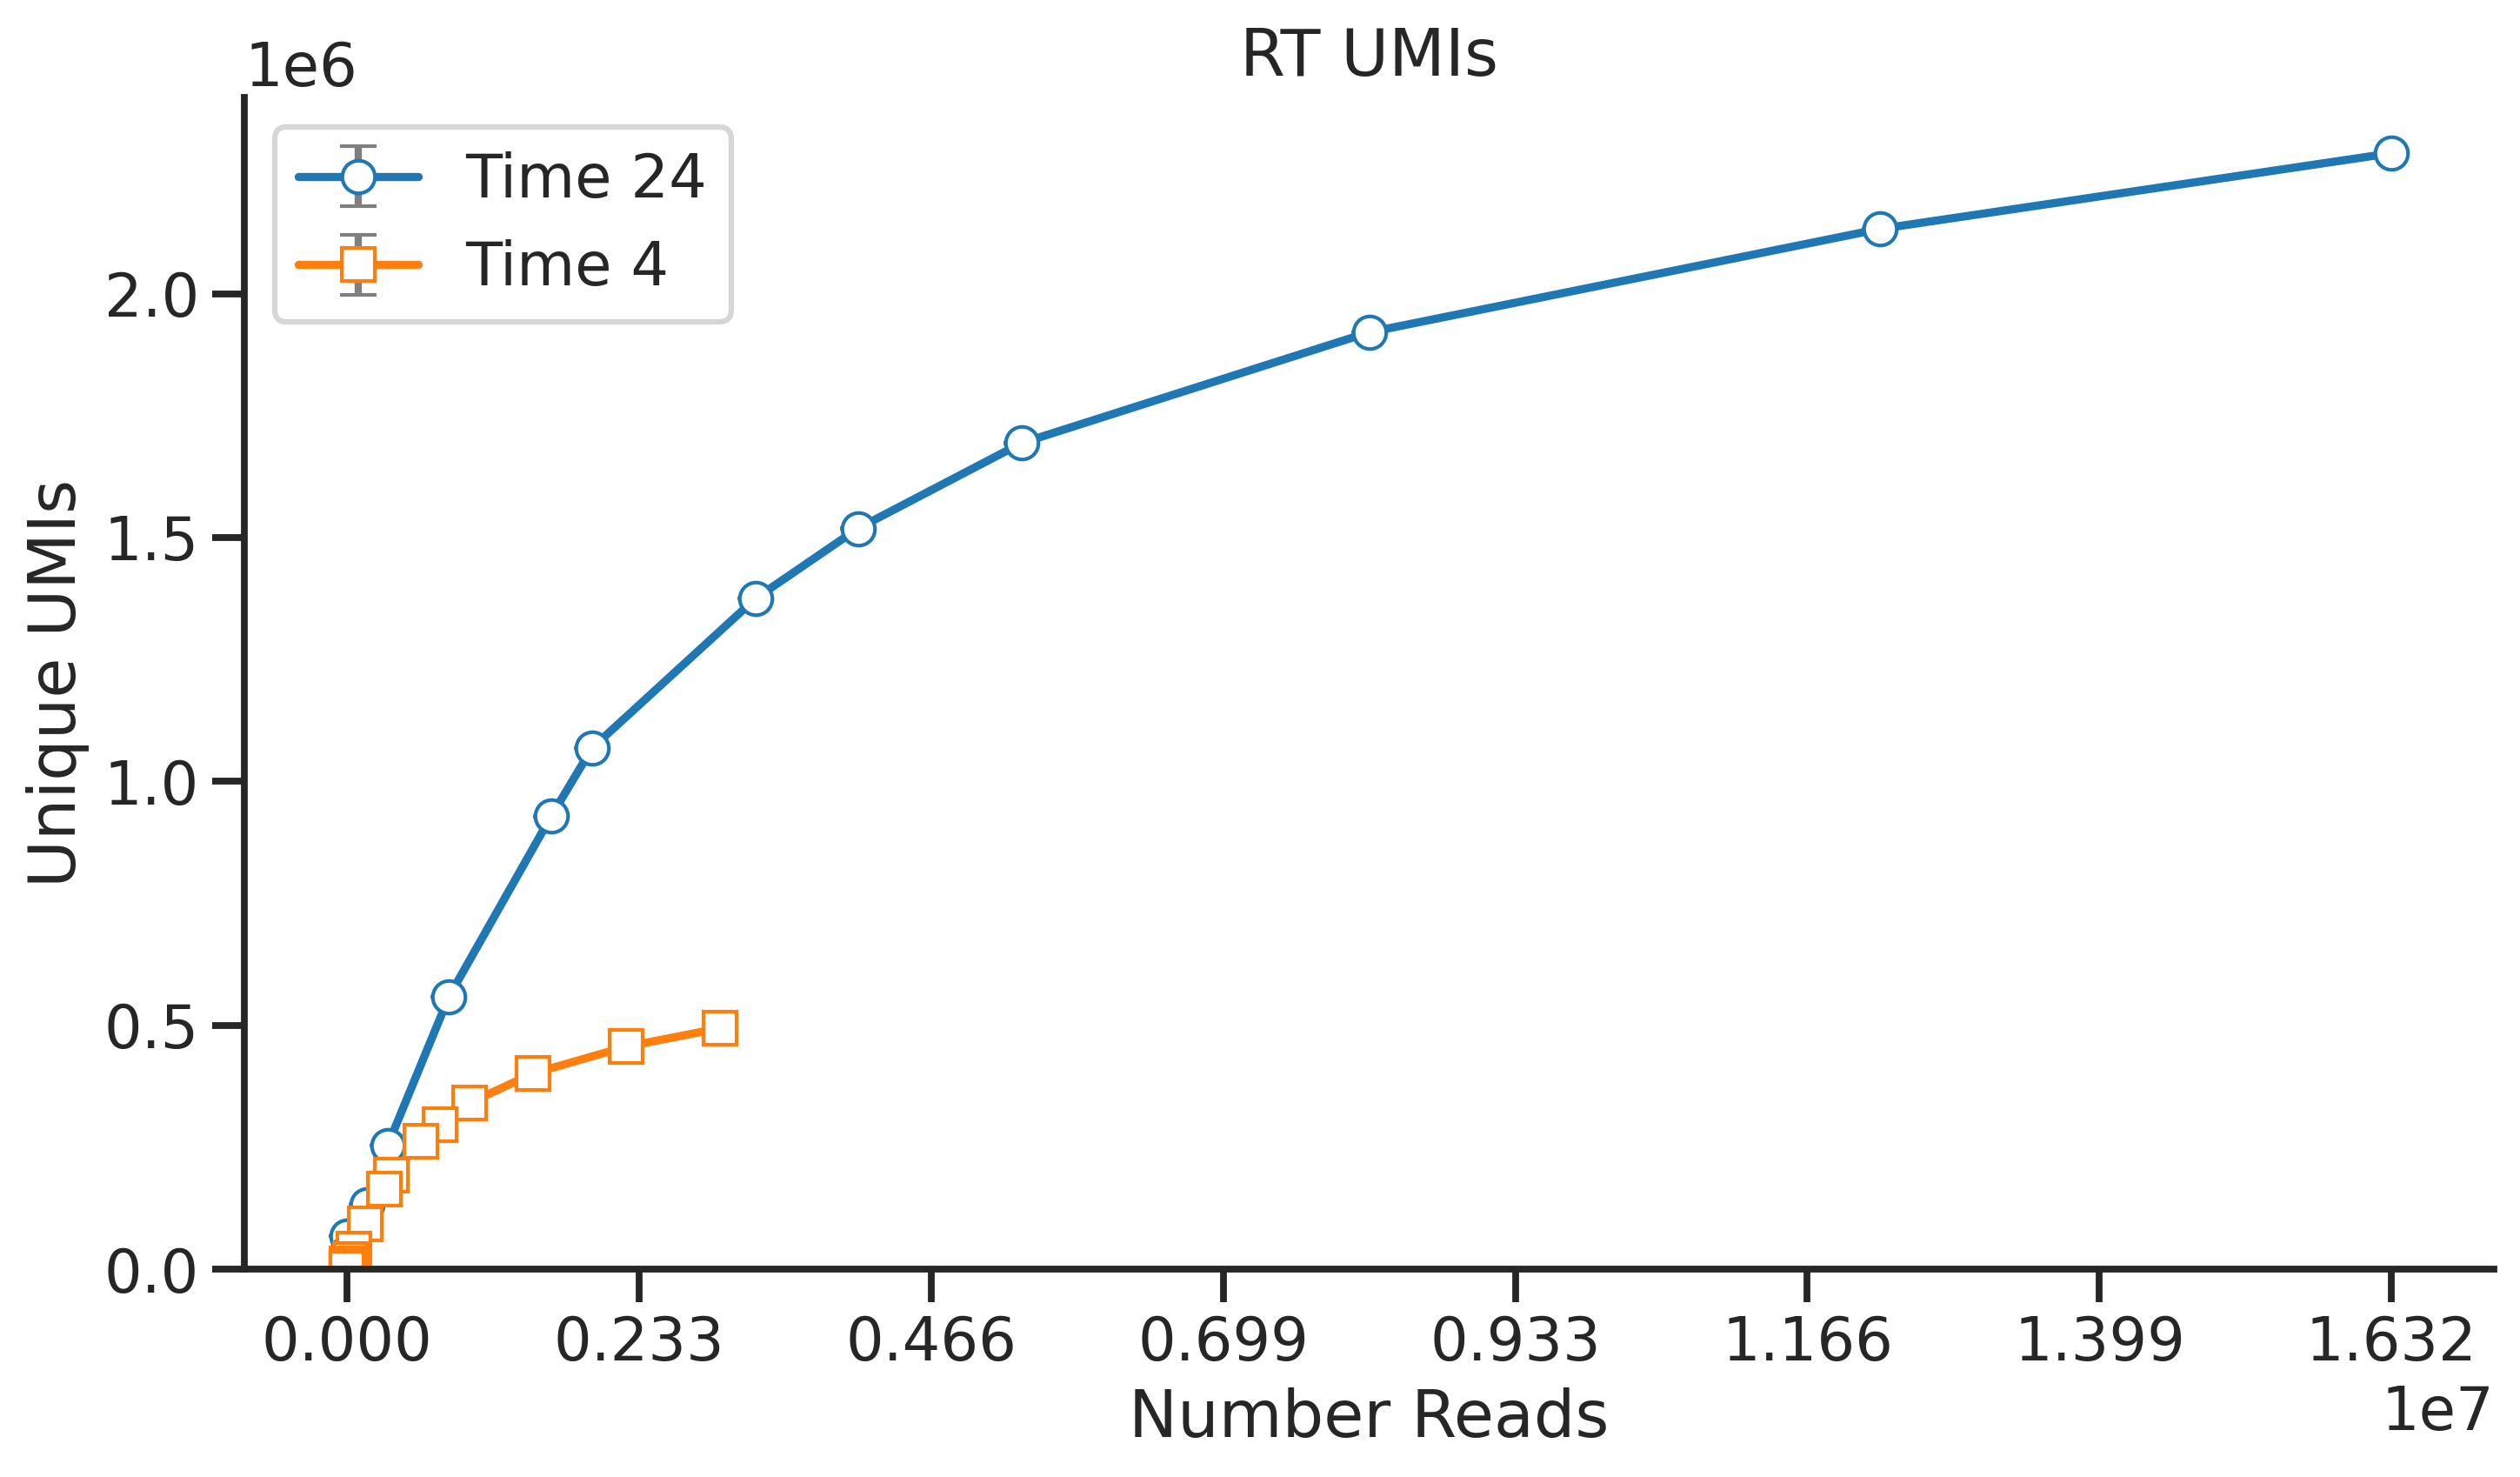

In [69]:
sns.set(style="ticks")
sns.set_context('talk')

plt.figure(figsize=(10,6), dpi=300)

# --- Time 30 ---
x_30 = time_24_summary['percent_reads'] * time_24_total_reads / 100
y_mean_30 = time_24_summary[('unique_umis', 'mean')]
y_std_30 = time_24_summary[('unique_umis', 'std')]

plt.errorbar(
    x=x_30,
    y=y_mean_30,
    yerr=y_std_30,
    fmt='-o',
    capsize=5,
    color='tab:blue',
    ecolor='tab:gray',
    elinewidth=2,
    markerfacecolor='white',
    label='Time 24'
)

# --- Time 5 ---
x_5 = time_4_summary['percent_reads'] * time_4_total_reads / 100
y_mean_5 = time_4_summary[('unique_umis', 'mean')]
y_std_5 = time_4_summary[('unique_umis', 'std')]

plt.errorbar(
    x=x_5,
    y=y_mean_5,
    yerr=y_std_5,
    fmt='-s',
    capsize=5,
    color='tab:orange',
    ecolor='tab:gray',
    elinewidth=2,
    markerfacecolor='white',
    label='Time 4'
)

# Labels, legend, title
plt.xlabel("Number Reads")
plt.ylabel("Unique UMIs")
plt.title("RT UMIs")

# --- Standard / more frequent x-ticks ---
all_x = np.concatenate([x_30, x_5])
plt.xticks(np.linspace(all_x.min(), all_x.max(), 8))  # 8 evenly spaced ticks

# plt.xlim(-10000000,)
plt.ylim(-1,)

plt.legend()
plt.tight_layout()
sns.despine()
plt.show()


In [70]:
time_4_summary.to_csv("../../output/nkx2-2_downsampling_t4_summary.csv")

In [71]:
time_24_summary.to_csv("../../output/nkx2-2_downsampling_t24_summary.csv")